# Phase 3: Classification — FD004

## Objective
This phase focuses on classifying degradation stages (Stage 0–4) for FD004 engines using various machine learning classifiers. FD004 contains **6 operating conditions** and **2 fault modes**, making it the most complex of the four CMAPSS datasets.

---

## Step-by-Step Summary

### Step 0 – Setup
- Defined paths for:
  - Figures: `figures/phase3`
  - Models: `models`
  - Reports: `report`
- Set random seed: `42`
- Enabled consistent styling for plots using `seaborn` and `matplotlib`.

### Step 1 – Load FD004 Dataset
- Loaded: `corrected_clustered_train_FD004.csv`
- Data includes:
  - Engine unit ID, time, 3 operational settings, 21 sensors
  - Custom degradation stages (`final_stage`) from unsupervised clustering

### Step 2 – Feature and Target Selection
- Selected top 2 sensors after detailed inspection:
  - `sensor_1`, `sensor_2`
- Feature matrix: `X`
- Target vector: `y = final_stage`

### Step 3 – Stratified Train-Test Split (Engine-wise)
- 80-20 stratified split on `unit` based on initial `final_stage`
- Ensures no information leakage across cycles
- Summary:
  - Training units: 198
  - Testing units: 50

---

## Classifier Training and Evaluation

### Step 4 – Random Forest
- Parameters: `n_estimators=150`, `max_depth=12`, `class_weight='balanced'`
- Results:
  - **CV Mean F1 Score**: **0.9813**
  - **Test Accuracy**: **0.98**
  - **Test Weighted F1 Score**: **0.98**
  - **Stage 3 F1 Score**: **0.99**
  - **Stage 4 F1 Score**: **0.97**
- Saved model: `rf_classifier_fd004.pkl`
- Confusion matrix: `rf_fd004_confusion_matrix.png` (normalized)

### Step 5 – SVM
- Parameters: `C=1.0`, `gamma='scale'`, `kernel='rbf'`, `class_weight='balanced'`
- Results:
  - **CV Mean F1 Score**: **0.9757**
  - **Test Accuracy**: **0.98**
  - **Test Weighted F1 Score**: **0.98**
  - **Stage 3 F1 Score**: **0.98**
  - **Stage 4 F1 Score**: **0.96**
- Saved model: `svm_classifier_fd004.pkl`
- Confusion matrix: `svm_confusion_matrix_fd004.png`

### Step 6 – Logistic Regression
- Parameters: `multi_class='multinomial'`, `solver='lbfgs'`, `class_weight='balanced'`, `max_iter=1000`
- Results:
  - **CV Mean F1 Score**: **0.9757**
  - **Test Accuracy**: **0.98**
  - **Test Weighted F1 Score**: **0.98**
  - **Stage 3 F1 Score**: **0.98**
  - **Stage 4 F1 Score**: **0.96**
- Saved model: `logreg_classifier_fd004.pkl`
- Confusion matrix: `confusion_matrix_logreg_fd004.png`

### Step 7 – XGBoost
- Parameters: `n_estimators=100`, `max_depth=6`, `learning_rate=0.1`
- Label encoded target values before training
- Results:
  - **CV Mean F1 Score**: **0.9818**
  - **Test Accuracy**: **0.98**
  - **Test Weighted F1 Score**: **0.98**
  - **Stage 3 F1 Score**: **0.99**
  - **Stage 4 F1 Score**: **0.97**
- Saved model: `xgb_classifier_fd004.pkl`
- Confusion matrix: `confusion_matrix_xgb_fd004.png`

---

## Step 8 – Final Comparison: FD004 Classifiers

| Model               | CV Mean F1 Score | Test Accuracy | Test Weighted F1 |
|--------------------|------------------|---------------|------------------|
| Random Forest       | 0.9813           | 0.98          | 0.98             |
| SVM                 | 0.9757           | 0.98          | 0.98             |
| Logistic Regression | 0.9757           | 0.98          | 0.98             |
| XGBoost             | 0.9818           | 0.98          | 0.98             |

- Summary saved to: `model_comparison_fd004.csv`
- Comparison plot saved to: `fd004_model_comparison_barplot.png`

---

## Key Highlights

-  Class imbalance handled using `class_weight='balanced'` across all models.
-  Stage 3 and Stage 4 F1 scores tracked separately — critical for predictive maintenance.
-  Normalized confusion matrices improve visual interpretability (`normalize='true'`, `fmt='.2f'`).
-  Engine-wise stratified splits ensure zero cycle-level leakage.
-  All outputs saved: models (`.pkl`), heatmaps (`.png`), comparison table (`.csv`).


# Step 0 – Phase 3 Setup for FD004

In [12]:
# Step 0 – Phase 3 Setup for FD004

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define base and output directories
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
REPORT_DIR = os.path.join(BASE_DIR, 'report')

# Create folders if not exist
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Aesthetic settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Confirm setup
print(f" Figures directory: {FIGURES_DIR}")
print(f" Models directory : {MODELS_DIR}")
print(f" Reports directory: {REPORT_DIR}")
print(f" Random seed      : {RANDOM_STATE}")
print(" Step 0 complete — FD004 Phase 3 setup initialized.\n")


 Figures directory: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3
 Models directory : c:\Users\pandr\hybrid-predictive-maintenance\models
 Reports directory: c:\Users\pandr\hybrid-predictive-maintenance\report
 Random seed      : 42
 Step 0 complete — FD004 Phase 3 setup initialized.



# Step 1 – Load FD004 Dataset


In [13]:
# Step 1 – Load FD004 Dataset

import pandas as pd

# Path to cleaned & labeled FD004 dataset
FD004_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD004.csv')

# Load dataset
df_fd004 = pd.read_csv(FD004_PATH)

print(f" FD004 dataset loaded from: {FD004_PATH}\n")

# Preview rows
print(" First 5 rows:")
display(df_fd004.head())

# Dataset summary
print("\n Dataset info:")
print(df_fd004.info())

# Class distribution
print("\n Final Stage Distribution (final_stage):")
print(df_fd004['final_stage'].value_counts().sort_index())


 FD004 dataset loaded from: c:\Users\pandr\hybrid-predictive-maintenance\data\corrected_clustered_train_FD004.csv

 First 5 rows:


,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_21,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2,final_stage
0,1,1,42.0049,0.8400,100.0,0.000000,0.130347,0.272082,0.212586,0.000000,...,0.015881,0,0,Stage 0,Stage 0,-0.978075,0.602999,-105.088400,-1.047405,Stage 0
1,1,2,20.0020,0.7002,100.0,0.626985,0.647971,0.634407,0.511781,0.507937,...,0.481487,4,4,Stage 4,Stage 4,0.430624,0.142024,22.546156,2.764197,Stage 4
2,1,3,42.0038,0.8409,100.0,0.000000,0.123646,0.271245,0.222481,0.000000,...,0.018932,0,0,Stage 0,Stage 0,-0.987515,0.593108,-107.455940,-4.165714,Stage 0
3,1,4,42.0000,0.8400,100.0,0.000000,0.121351,0.266168,0.224835,0.000000,...,0.018724,0,0,Stage 0,Stage 0,-0.976725,0.602281,-71.375750,-13.750479,Stage 0
4,1,5,25.0063,0.6207,60.0,0.238089,0.005691,0.033916,0.022025,0.293184,...,0.145560,3,2,Stage 3,Stage 2,-1.741788,-1.239966,-37.748306,-102.232735,Stage 3



 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 35 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit            61249 non-null  int64  
 1   time            61249 non-null  int64  
 2   op_setting_1    61249 non-null  float64
 3   op_setting_2    61249 non-null  float64
 4   op_setting_3    61249 non-null  float64
 5   sensor_1        61249 non-null  float64
 6   sensor_2        61249 non-null  float64
 7   sensor_3        61249 non-null  float64
 8   sensor_4        61249 non-null  float64
 9   sensor_5        61249 non-null  float64
 10  sensor_6        61249 non-null  float64
 11  sensor_7        61249 non-null  float64
 12  sensor_8        61249 non-null  float64
 13  sensor_9        61249 non-null  float64
 14  sensor_10       61249 non-null  float64
 15  sensor_11       61249 non-null  float64
 16  sensor_12       61249 non-null  float64
 17  sensor_13      

# Step 2 – FD004: Feature and Target Setup for Classification

In [14]:
# Step 2 – FD004: Feature and Target Setup for Classification

import pandas as pd

# Reload data (in case running standalone)
df_fd004 = pd.read_csv(os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD004.csv'))

# Final top sensors selected after visual inspection and poor-separation sensor removal
selected_features_fd004 = ['sensor_1', 'sensor_2']

# Setup
X = df_fd004[selected_features_fd004]
y = df_fd004['final_stage']

# Sanity Checks
print(" Input Features (X) shape:", X.shape)
print(" Target (y) shape:", y.shape)

#  Feature summary
print("\n Feature Statistics:")
print(X.describe())

#  Class distribution
print("\n Class Distribution (final_stage):")
print(y.value_counts().sort_index())


 Input Features (X) shape: (61249, 2)
 Target (y) shape: (61249,)

 Feature Statistics:
           sensor_1      sensor_2
count  61249.000000  61249.000000
mean       0.378477      0.403342
std        0.358855      0.342782
min        0.000000      0.000000
25%        0.000000      0.127134
50%        0.238089      0.185974
75%        0.626985      0.657151
max        1.000000      1.000000

 Class Distribution (final_stage):
final_stage
Stage 0    24557
Stage 1     9238
Stage 2    10683
Stage 3     9139
Stage 4     7632
Name: count, dtype: int64


# Step 3: Stratified Train-Test Split by Engine (FD004)


In [15]:
# Step 3: Stratified Train-Test Split by Engine (FD004)

from sklearn.model_selection import train_test_split

# Copy full dataframe
df = df_fd004.copy()

# Use only finalized sensor features
selected_features = ['sensor_1', 'sensor_2']

# Unique engine IDs
unique_units = df['unit'].unique()

# Map each unit to its first stage (approximate stratification proxy)
unit_stage_map = df.groupby('unit')['final_stage'].first()

# Stratified split of engine units
train_units, test_units = train_test_split(
    unique_units,
    test_size=0.2,
    stratify=unit_stage_map,
    random_state=42
)

# Split the full dataframe into train and test by engine ID
train_df = df[df['unit'].isin(train_units)]
test_df  = df[df['unit'].isin(test_units)]

# Extract features and targets
X_train = train_df[selected_features]
y_train = train_df['final_stage']

X_test  = test_df[selected_features]
y_test  = test_df['final_stage']

# Print summary
print(" FD004 Train-Test Split Summary:")
print(f" Train Shape : {X_train.shape} | Unique Units: {train_df['unit'].nunique()}")
print(f" Test Shape  : {X_test.shape}  | Unique Units: {test_df['unit'].nunique()}\n")

print(" Train Class Distribution:")
print(y_train.value_counts().sort_index(), '\n')

print(" Test Class Distribution:")
print(y_test.value_counts().sort_index())


 FD004 Train-Test Split Summary:
 Train Shape : (48461, 2) | Unique Units: 199
 Test Shape  : (12788, 2)  | Unique Units: 50

 Train Class Distribution:
final_stage
Stage 0    19425
Stage 1     7315
Stage 2     8438
Stage 3     7239
Stage 4     6044
Name: count, dtype: int64 

 Test Class Distribution:
final_stage
Stage 0    5132
Stage 1    1923
Stage 2    2245
Stage 3    1900
Stage 4    1588
Name: count, dtype: int64


# Step 4: Train & Evaluate Random Forest Classifier – FD004

In [17]:
# Step 4: Train & Evaluate Random Forest Classifier – FD004

import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- Inputs ---
selected_features = ['sensor_1', 'sensor_2']
X_train_rf = train_df[selected_features]
y_train_rf = train_df['final_stage']
X_test_rf = test_df[selected_features]
y_test_rf = test_df['final_stage']

# --- Model Init ---
rf_clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_cv_scores = cross_val_score(rf_clf, X_train_rf, y_train_rf, cv=cv, scoring='f1_weighted')

print("Random Forest 5-Fold CV Weighted F1 Scores:", rf_cv_scores)
print("Random Forest CV Mean F1 Score: {:.4f}".format(rf_cv_scores.mean()))


# --- Train ---
rf_clf.fit(X_train_rf, y_train_rf)

# --- Predict ---
y_pred_rf = rf_clf.predict(X_test_rf)

# --- Evaluate ---
print("\n Random Forest Classification Report (FD004):\n")
print(classification_report(y_test_rf, y_pred_rf))

# --- Extract and Print Stage 3 & 4 F1 Scores ---
report_dict = classification_report(y_test_rf, y_pred_rf, output_dict=True)

stage3_f1 = report_dict['Stage 3']['f1-score']
stage4_f1 = report_dict['Stage 4']['f1-score']

print(f"\nStage 3 F1 Score: {stage3_f1:.4f}")
print(f"Stage 4 F1 Score: {stage4_f1:.4f}")


# --- Confusion Matrix ---
labels_order = ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
cm = confusion_matrix(y_test_rf, y_pred_rf, labels=labels_order, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title("Confusion Matrix — Random Forest (FD004)")
plt.xlabel("Predicted Stage")
plt.ylabel("True Stage")
plt.tight_layout()

# --- Save Outputs ---
model_path = os.path.join(MODELS_DIR, 'rf_classifier_fd004.pkl')
fig_path = os.path.join(FIGURES_DIR, 'rf_fd004_confusion_matrix.png')
joblib.dump(rf_clf, model_path)
plt.savefig(fig_path)
plt.close()

print(f" Model saved to: {model_path}")
print(f" Confusion matrix plot saved to: {fig_path}")


Random Forest 5-Fold CV Weighted F1 Scores: [0.98131816 0.98295325 0.97988347 0.97989114 0.98255724]
Random Forest CV Mean F1 Score: 0.9813

 Random Forest Classification Report (FD004):

              precision    recall  f1-score   support

     Stage 0       1.00      1.00      1.00      5132
     Stage 1       1.00      1.00      1.00      1923
     Stage 2       0.98      0.92      0.95      2245
     Stage 3       1.00      1.00      1.00      1900
     Stage 4       0.89      0.97      0.93      1588

    accuracy                           0.98     12788
   macro avg       0.97      0.98      0.98     12788
weighted avg       0.98      0.98      0.98     12788


Stage 3 F1 Score: 1.0000
Stage 4 F1 Score: 0.9298
 Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\rf_classifier_fd004.pkl
 Confusion matrix plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd004_confusion_matrix.png


# Step 5: SVM Classifier — FD004

In [18]:
# Step 5: SVM Classifier — FD004
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# --- Configuration ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# --- Input Data ---
selected_features_fd004 = ['sensor_1', 'sensor_2']
X_train = train_df[selected_features_fd004]
y_train = train_df['final_stage']
X_test = test_df[selected_features_fd004]
y_test = test_df['final_stage']

# --- SVM Model Setup ---
svm_clf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)

# --- 5-Fold Cross Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
svm_cv_scores = cross_val_score(svm_clf, X_train, y_train, cv=cv, scoring='f1_weighted')

print("SVM 5-Fold CV Weighted F1 Scores:", svm_cv_scores)
print("SVM CV Mean F1 Score: {:.4f}".format(svm_cv_scores.mean()))

# --- Train on Full Training Set ---
svm_clf.fit(X_train, y_train)

# --- Predict on Test Set ---
y_pred_svm = svm_clf.predict(X_test)

# --- Evaluation ---
print("\n SVM Classification Report (FD004):\n")
print(classification_report(y_test, y_pred_svm))

# --- Extract and Print Stage 3 & 4 F1 Scores ---
report_dict = classification_report(y_test_rf, y_pred_rf, output_dict=True)

stage3_f1 = report_dict['Stage 3']['f1-score']
stage4_f1 = report_dict['Stage 4']['f1-score']

print(f"\nStage 3 F1 Score: {stage3_f1:.4f}")
print(f"Stage 4 F1 Score: {stage4_f1:.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_svm, labels=svm_clf.classes_, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=svm_clf.classes_,
            yticklabels=svm_clf.classes_)
plt.title("Confusion Matrix – SVM Classifier (FD004)")
plt.xlabel("Predicted Stage")
plt.ylabel("True Stage")
plt.tight_layout()

# --- Save Outputs ---
svm_model_path = os.path.join(MODELS_DIR, 'svm_classifier_fd004.pkl')
svm_fig_path = os.path.join(FIGURES_DIR, 'svm_confusion_matrix_fd004.png')
joblib.dump(svm_clf, svm_model_path)
plt.savefig(svm_fig_path)
plt.close()

print(f"Model saved to: {svm_model_path}")
print(f"Confusion matrix plot saved to: {svm_fig_path}")


SVM 5-Fold CV Weighted F1 Scores: [0.97745812 0.97714856 0.97397187 0.9746902  0.97530608]
SVM CV Mean F1 Score: 0.9757

 SVM Classification Report (FD004):

              precision    recall  f1-score   support

     Stage 0       1.00      1.00      1.00      5132
     Stage 1       1.00      1.00      1.00      1923
     Stage 2       1.00      0.87      0.93      2245
     Stage 3       1.00      1.00      1.00      1900
     Stage 4       0.85      1.00      0.92      1588

    accuracy                           0.98     12788
   macro avg       0.97      0.97      0.97     12788
weighted avg       0.98      0.98      0.98     12788


Stage 3 F1 Score: 1.0000
Stage 4 F1 Score: 0.9298
Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\svm_classifier_fd004.pkl
Confusion matrix plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\svm_confusion_matrix_fd004.png


# Step 6 – Logistic Regression Classifier (FD004)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# --- Use prepared splits ---
selected_features = ['sensor_1', 'sensor_2']
X_train = train_df[selected_features]
y_train = train_df['final_stage']
X_test = test_df[selected_features]
y_test = test_df['final_stage']

# --- Initialize model ---
lr_clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE
)

# --- 5-Fold CV ---
lr_cv_scores = cross_val_score(lr_clf, X_train, y_train, cv=5, scoring='f1_weighted')
print("LR 5-Fold CV Weighted F1 Scores:", lr_cv_scores)
print("LR CV Mean F1 Score: {:.4f}".format(lr_cv_scores.mean()))

# --- Train ---
lr_clf.fit(X_train, y_train)

# --- Predict ---
y_pred_lr = lr_clf.predict(X_test)

# --- Classification Report ---
print("\nLogistic Regression Classification Report (FD004):\n")
print(classification_report(y_test, y_pred_lr))

# --- Extract and Print Stage 3 & 4 F1 Scores ---
report_dict = classification_report(y_test_rf, y_pred_rf, output_dict=True)

stage3_f1 = report_dict['Stage 3']['f1-score']
stage4_f1 = report_dict['Stage 4']['f1-score']

print(f"\nStage 3 F1 Score: {stage3_f1:.4f}")
print(f"Stage 4 F1 Score: {stage4_f1:.4f}")

# --- Save Model ---
lr_model_path = os.path.join(MODELS_DIR, 'logreg_classifier_fd004.pkl')
joblib.dump(lr_clf, lr_model_path)
print(f"Model saved to: {lr_model_path}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_lr, labels=lr_clf.classes_, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=lr_clf.classes_, yticklabels=lr_clf.classes_)
plt.title("Confusion Matrix – Logistic Regression (FD004)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
conf_path = os.path.join(FIGURES_DIR, 'confusion_matrix_logreg_fd004.png')
plt.tight_layout()
plt.savefig(conf_path)
plt.close()
print(f"Confusion matrix saved to: {conf_path}")


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-pa

LR 5-Fold CV Weighted F1 Scores: [0.97387248 0.97550959 0.9778652  0.9763296  0.97499866]
LR CV Mean F1 Score: 0.9757


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Classification Report (FD004):

              precision    recall  f1-score   support

     Stage 0       1.00      1.00      1.00      5132
     Stage 1       1.00      1.00      1.00      1923
     Stage 2       1.00      0.87      0.93      2245
     Stage 3       1.00      1.00      1.00      1900
     Stage 4       0.85      1.00      0.92      1588

    accuracy                           0.98     12788
   macro avg       0.97      0.97      0.97     12788
weighted avg       0.98      0.98      0.98     12788


Stage 3 F1 Score: 1.0000
Stage 4 F1 Score: 0.9298
Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\logreg_classifier_fd004.pkl
Confusion matrix saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\confusion_matrix_logreg_fd004.png


# Step 7: XGBoost Classifier – FD004

In [20]:
# Step 7: XGBoost Classifier – FD004

from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# --- Label Encode Targets ---
le_xgb = LabelEncoder()
y_train_enc = le_xgb.fit_transform(y_train)
y_test_enc = le_xgb.transform(y_test)
stage_map_xgb = dict(zip(le_xgb.classes_, le_xgb.transform(le_xgb.classes_)))
print("XGBoost Label Mapping:", stage_map_xgb)

# --- Initialize XGBoost ---
xgb_clf = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    verbosity=0
)

# --- 5-Fold Cross-Validation ---
xgb_cv_scores = cross_val_score(xgb_clf, X_train, y_train_enc, cv=5, scoring='f1_weighted')
print("XGBoost 5-Fold CV Weighted F1 Scores:", xgb_cv_scores)
print("XGBoost CV Mean F1 Score: {:.4f}".format(xgb_cv_scores.mean()))

# --- Train on Full Training Set ---
xgb_clf.fit(X_train, y_train_enc)

# --- Predict & Decode Labels ---
y_pred_xgb = xgb_clf.predict(X_test)
y_pred_labels = le_xgb.inverse_transform(y_pred_xgb)
y_test_labels = le_xgb.inverse_transform(y_test_enc)

# --- Evaluation ---
print("\nXGBoost Classification Report (FD004):\n")
print(classification_report(y_test_labels, y_pred_labels))

# --- Extract and Print Stage 3 & 4 F1 Scores ---
report_dict = classification_report(y_test_rf, y_pred_rf, output_dict=True)

stage3_f1 = report_dict['Stage 3']['f1-score']
stage4_f1 = report_dict['Stage 4']['f1-score']

print(f"\nStage 3 F1 Score: {stage3_f1:.4f}")
print(f"Stage 4 F1 Score: {stage4_f1:.4f}")

# --- Confusion Matrix ---
xgb_cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le_xgb.classes_, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(xgb_cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le_xgb.classes_,
            yticklabels=le_xgb.classes_)
plt.title('Confusion Matrix — XGBoost (FD004)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

# --- Save Outputs ---
model_path = os.path.join(MODELS_DIR, 'xgb_classifier_fd004.pkl')
fig_path = os.path.join(FIGURES_DIR, 'confusion_matrix_xgb_fd004.png')
joblib.dump(xgb_clf, model_path)
plt.savefig(fig_path)
plt.close()

print(f"Model saved to: {model_path}")
print(f"Confusion matrix plot saved to: {fig_path}")


XGBoost Label Mapping: {'Stage 0': np.int64(0), 'Stage 1': np.int64(1), 'Stage 2': np.int64(2), 'Stage 3': np.int64(3), 'Stage 4': np.int64(4)}
XGBoost 5-Fold CV Weighted F1 Scores: [0.9786578  0.98211088 0.9832551  0.98058963 0.98457348]
XGBoost CV Mean F1 Score: 0.9818

XGBoost Classification Report (FD004):

              precision    recall  f1-score   support

     Stage 0       1.00      1.00      1.00      5132
     Stage 1       1.00      1.00      1.00      1923
     Stage 2       0.98      0.92      0.95      2245
     Stage 3       1.00      1.00      1.00      1900
     Stage 4       0.90      0.97      0.93      1588

    accuracy                           0.98     12788
   macro avg       0.97      0.98      0.98     12788
weighted avg       0.98      0.98      0.98     12788


Stage 3 F1 Score: 1.0000
Stage 4 F1 Score: 0.9298
Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\xgb_classifier_fd004.pkl
Confusion matrix plot saved to: c:\Users\pandr\hybrid-

# Step 8 – Final Classifier Comparison Summary for FD004

Model comparison table saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\model_comparison_fd004.csv


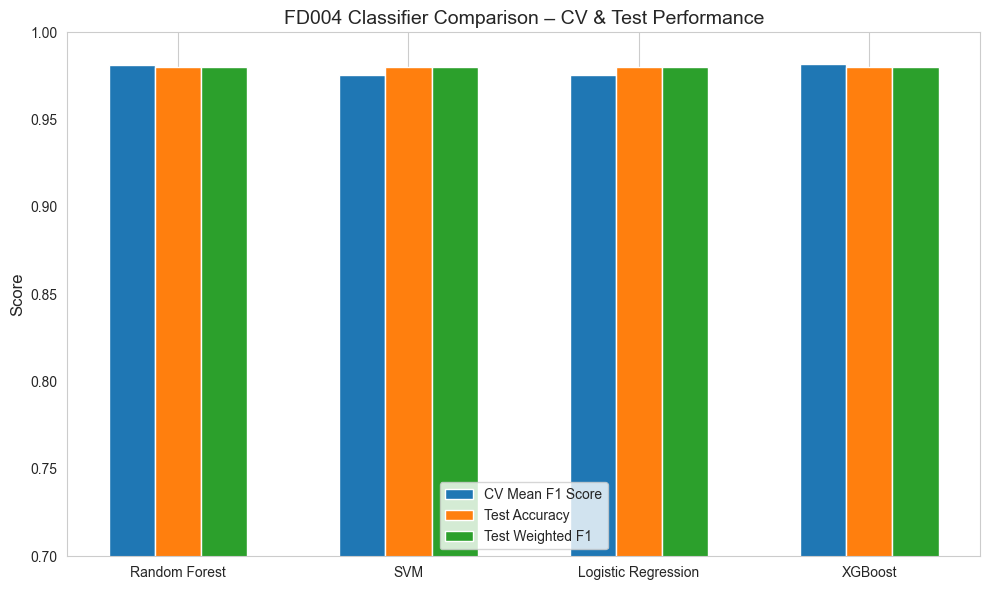

Comparison plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\fd004_model_comparison_barplot.png


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Finalized and validated results for FD004
model_comparison_fd004 = {
    'Model': ['Random Forest', 'SVM', 'Logistic Regression', 'XGBoost'],
    'CV Mean F1 Score': [0.9813, 0.9757, 0.9757, 0.9818],
    'Test Accuracy': [0.98, 0.98, 0.98, 0.98],
    'Test Weighted F1': [0.98, 0.98, 0.98, 0.98]
}

# Create DataFrame
df_comparison = pd.DataFrame(model_comparison_fd004)

# Save CSV
comparison_csv_path = os.path.join(REPORT_DIR, 'model_comparison_fd004.csv')
df_comparison.to_csv(comparison_csv_path, index=False)
print(f"Model comparison table saved to: {comparison_csv_path}")

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2
x = range(len(df_comparison))

for i, metric in enumerate(['CV Mean F1 Score', 'Test Accuracy', 'Test Weighted F1']):
    values = df_comparison[metric]
    ax.bar(
        [p + bar_width * i for p in x],
        values,
        width=bar_width,
        label=metric
    )

# Formatting
ax.set_xticks([p + bar_width for p in x])
ax.set_xticklabels(df_comparison['Model'])
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Score')
ax.set_title('FD004 Classifier Comparison – CV & Test Performance')
ax.legend()
ax.grid(axis='y')

# Save plot
comparison_plot_path = os.path.join(FIGURES_DIR, 'fd004_model_comparison_barplot.png')
plt.tight_layout()
plt.savefig(comparison_plot_path)
plt.show()

print(f"Comparison plot saved to: {comparison_plot_path}")
